In [2]:
# set up
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc

In [ ]:
# settings & figure params
sc.settings.verbosity = 1  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

/tmp/ipykernel_8332/3938469974.py:3: FutureWarning: Use `print_header` instead
  sc.logging.print_versions()
/tmp/ipykernel_8332/3938469974.py:4: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")


In [4]:
# this is an earlier version of the dataset from the classic pbmc3k tutorial
adata_ref = sc.datasets.pbmc3k_processed() # annotated dataset
adata = sc.datasets.pbmc68k_reduced() # dataset for which we want to query labels and embeddings

/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 23.5M/23.5M [00:00<00:00, 127MB/s]


In [5]:
# define on same variables
var_names = adata_ref.var_names.intersection(adata.var_names)
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

In [6]:
# PCA, neighbors, UMAP
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)


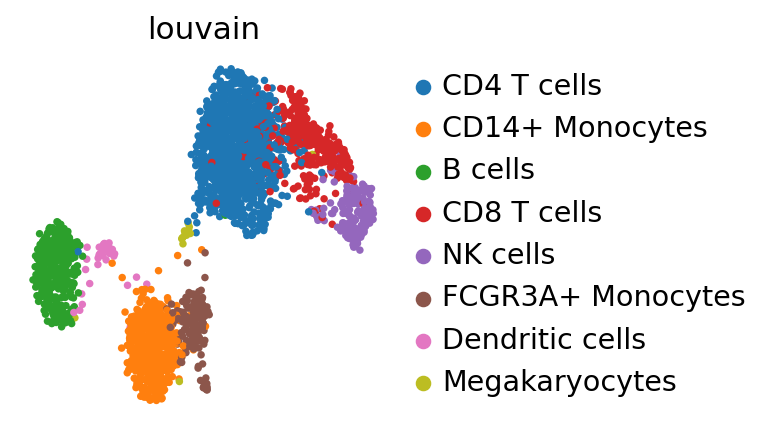

In [7]:
# manifold
sc.pl.umap(adata_ref, color="louvain")

In [8]:
# mapping PBMCs using ingest
sc.tl.ingest(adata, adata_ref, obs="louvain")

In [9]:
adata.uns["louvain_colors"] = adata_ref.uns["louvain_colors"]  # fix colors

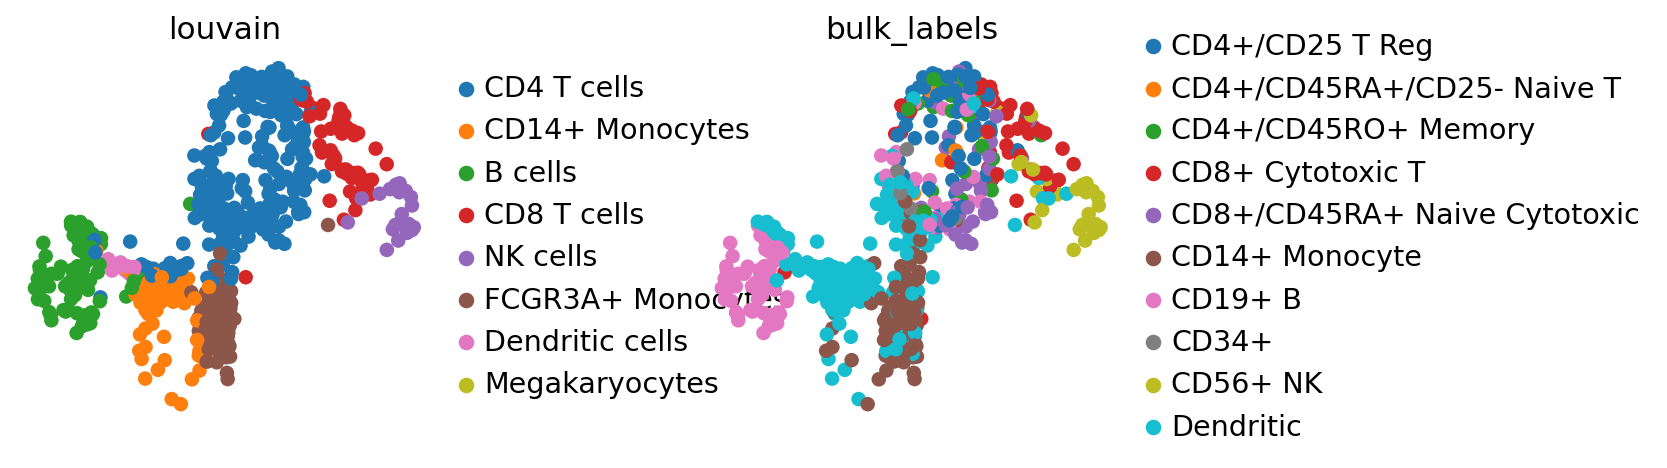

In [ ]:
# UMAP with bulk labels
sc.pl.umap(adata, color=["louvain", "bulk_labels"], wspace=0.5)

In [11]:
adata_concat = anndata.concat([adata_ref, adata], label="batch", keys=["ref", "new"])

In [12]:
adata_concat.obs["louvain"] = (
    adata_concat.obs["louvain"].astype("category").cat.reorder_categories(adata_ref.obs["louvain"].cat.categories)
)
# fix category colors
adata_concat.uns["louvain_colors"] = adata_ref.uns["louvain_colors"]

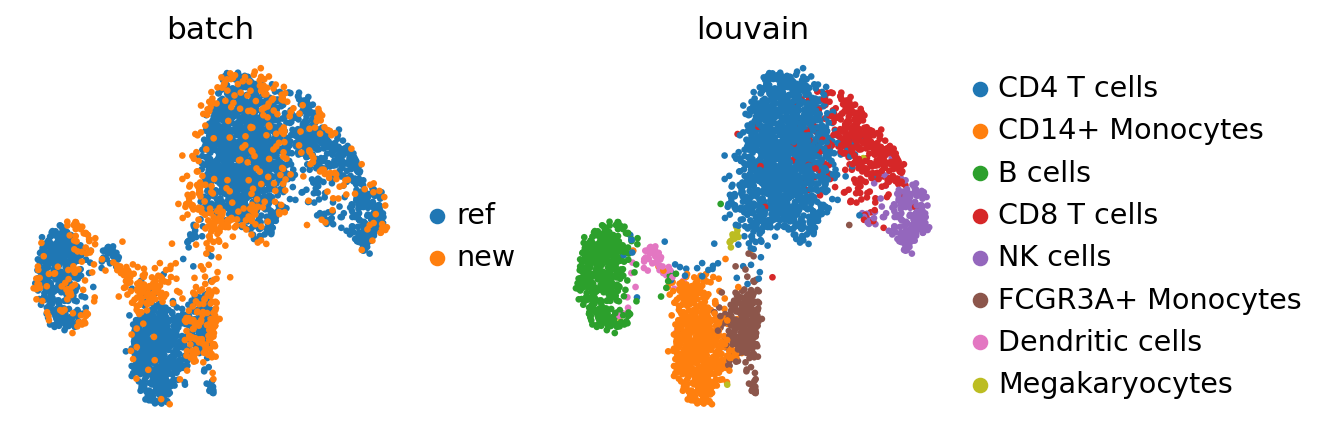

In [13]:
# batch UMAP
sc.pl.umap(adata_concat, color=["batch", "louvain"])

In [22]:
sc.tl.pca(adata_concat)

In [23]:
# BBKNN for comparison
sc.external.pp.bbknn(adata_concat, batch_key="batch")  # running bbknn 1.3.6

In [24]:
sc.tl.umap(adata_concat)

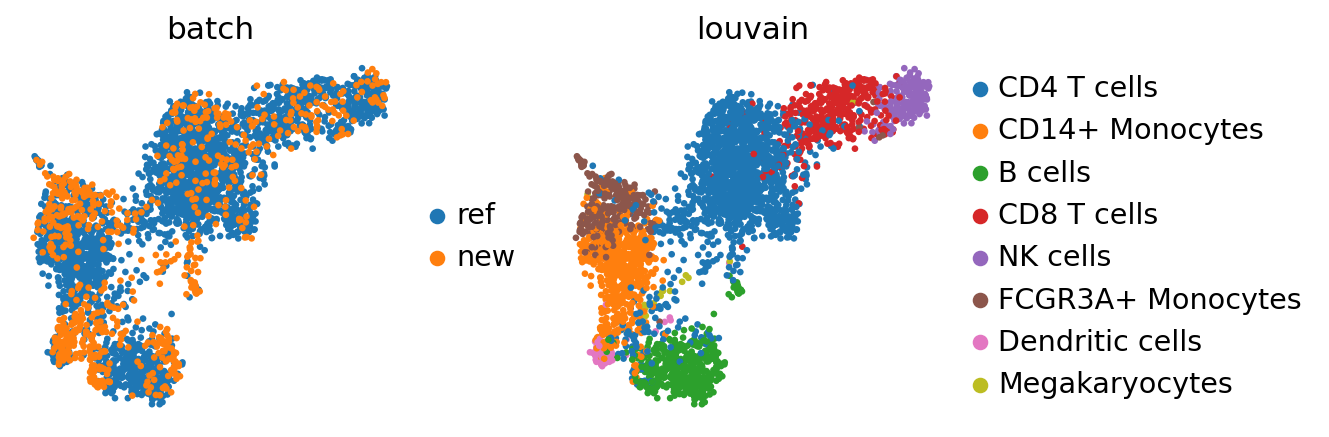

In [25]:
sc.pl.umap(adata_concat, color=["batch", "louvain"])


In [3]:
# pancreatic data human pancreas from 4 different studies [Baron et al., 2016, Muraro et al., 2016, Segerstolpe et al., 2016, Wang et al., 2016]
# note that this collection of batches is already intersected on the genes
adata_all = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)

/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [4]:
adata_all.shape

(14693, 2448)

In [5]:
# inspect the cell types observed in these studies
counts = adata_all.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [6]:
# simplify by removing 5 minority classes
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
adata_all = adata_all[~adata_all.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
adata_all.obs["celltype"] = adata_all.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())

In [7]:
# see the batch effect
sc.pp.pca(adata_all)
sc.pp.neighbors(adata_all)
sc.tl.umap(adata_all)

/workspaces/Scanpy_Ingest_BBKNN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


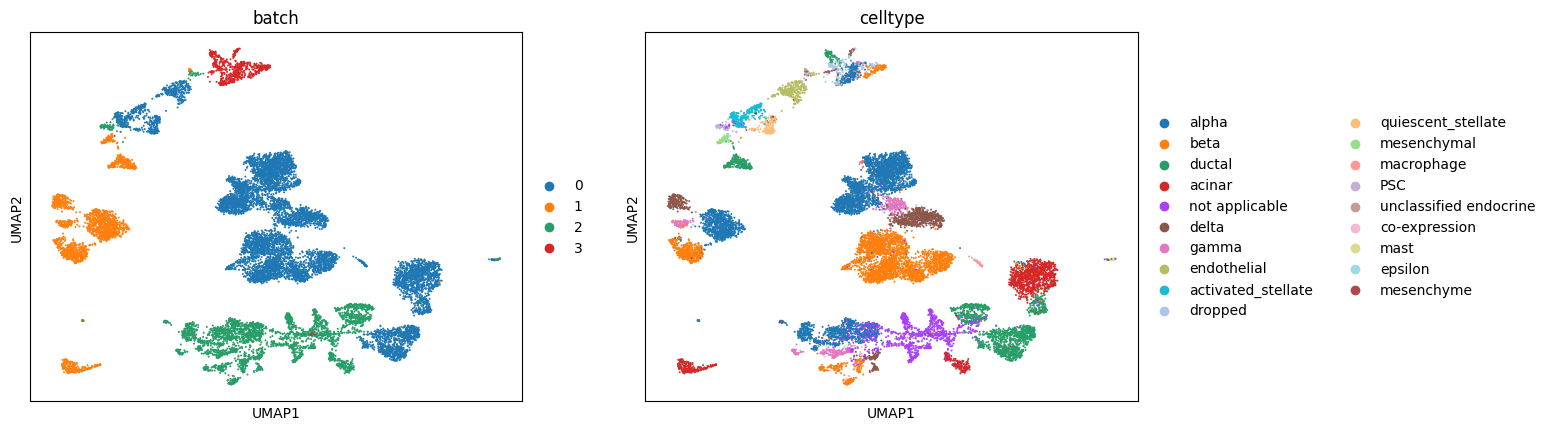

In [8]:
sc.pl.umap(adata_all, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

In [9]:
# BBKNN
sc.external.pp.bbknn(adata_all, batch_key="batch")

In [10]:
sc.tl.umap(adata_all)


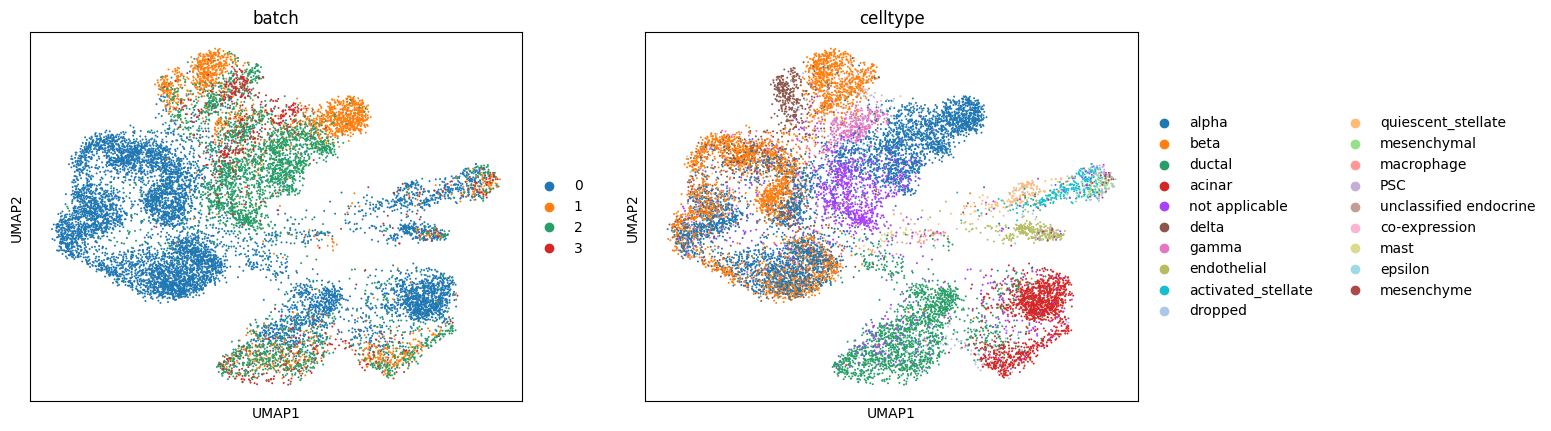

In [11]:
sc.pl.umap(adata_all, color=["batch", "celltype"])

In [13]:
# mapping onto a reference batch using ingest
adata_ref = adata_all[adata_all.obs["batch"] == "0"].copy()

In [14]:
# PCA, neighbors, and UMAP
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)

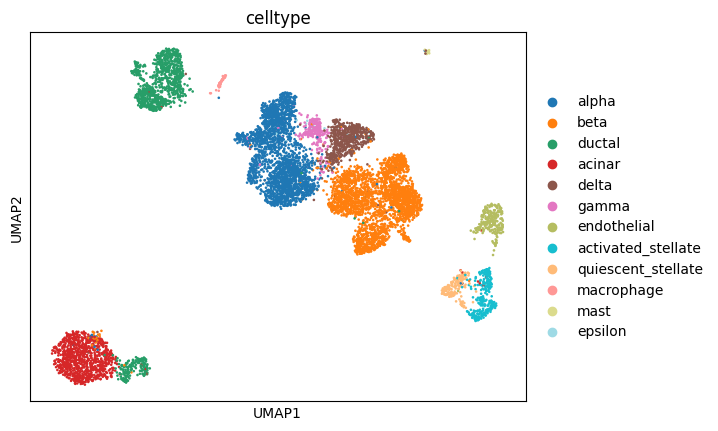

In [15]:
sc.pl.umap(adata_ref, color="celltype")

In [16]:
adatas = [adata_all[adata_all.obs["batch"] == i].copy() for i in ["1", "2", "3"]]

In [17]:
sc.settings.verbosity = 2  # a bit more logging
for iadata, adata in enumerate(adatas, 1):
    print(f"... integrating batch {iadata}")
    adata.obs["celltype_orig"] = adata.obs["celltype"]  # save the original cell type
    sc.tl.ingest(adata, adata_ref, obs="celltype")

... integrating batch 1
running ingest
    finished (0:00:08)
... integrating batch 2
running ingest
    finished (0:00:03)
... integrating batch 3
running ingest
    finished (0:00:02)


In [18]:
adata_concat = anndata.concat([adata_ref, *adatas], label="batch", join="outer")

In [19]:
adata_concat.obs["celltype"] = (
    adata_concat.obs["celltype"].astype("category").cat.reorder_categories(adata_ref.obs["celltype"].cat.categories)
)
# fix category coloring
adata_concat.uns["celltype_colors"] = adata_ref.uns["celltype_colors"]

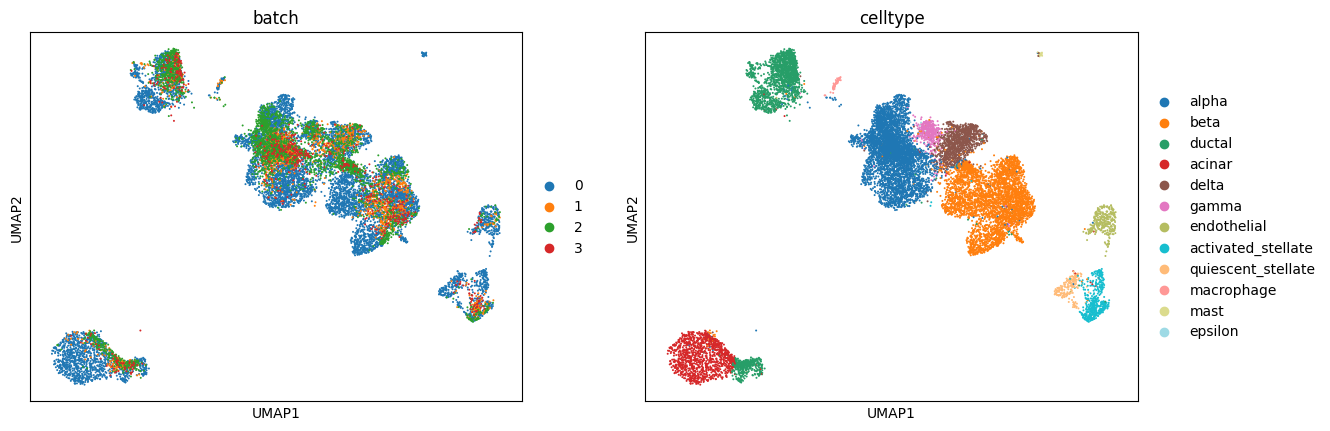

In [20]:
sc.pl.umap(adata_concat, color=["batch", "celltype"])

In [22]:
# evaluating consistency
adata_query = adata_concat[adata_concat.obs["batch"].isin(["1", "2", "3"])].copy()

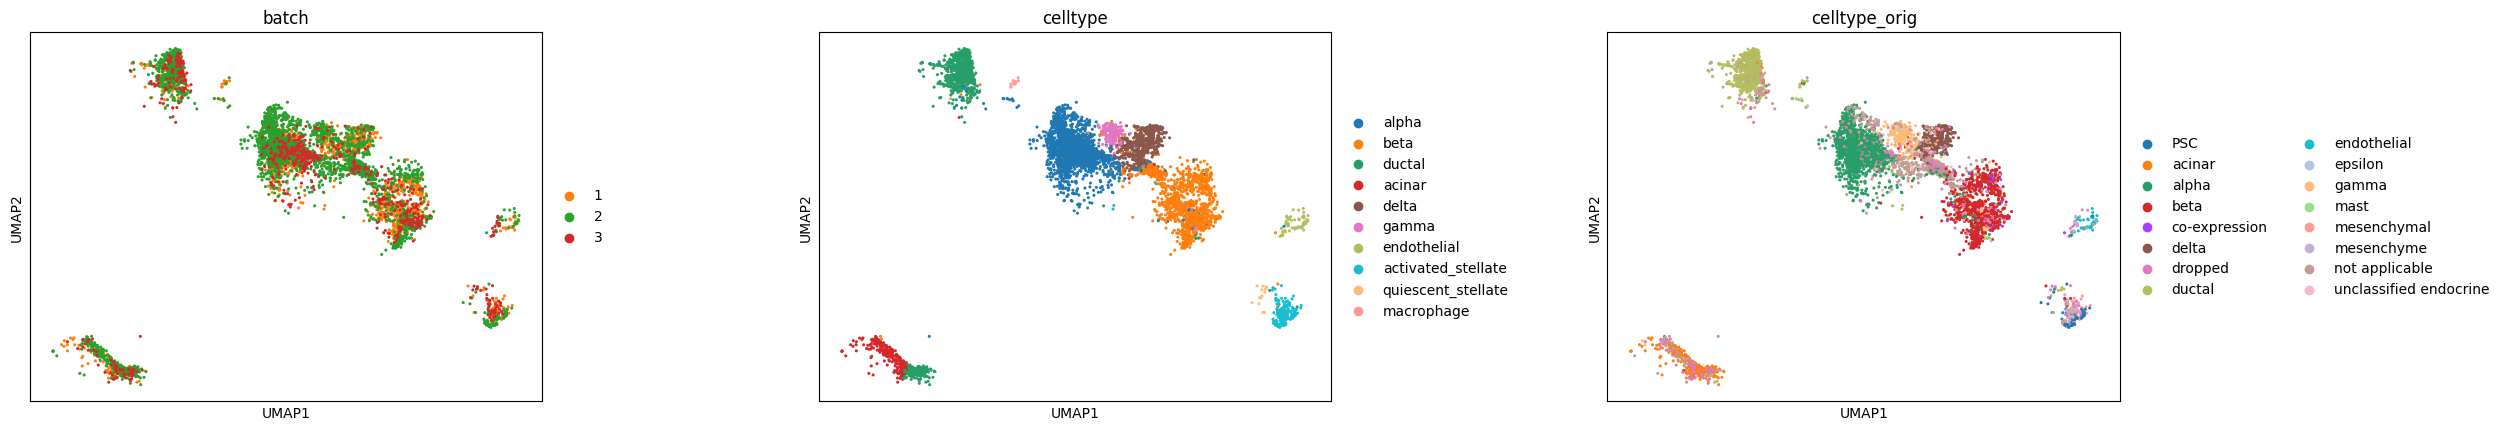

In [23]:
sc.pl.umap(adata_query, color=["batch", "celltype", "celltype_orig"], wspace=0.4)

In [24]:
# cell types conserved across batches
# intersected categories
conserved_categories = adata_query.obs["celltype"].cat.categories.intersection(
    adata_query.obs["celltype_orig"].cat.categories
)
# intersect categories
obs_query_conserved = adata_query.obs.loc[
    adata_query.obs["celltype"].isin(conserved_categories) & adata_query.obs["celltype_orig"].isin(conserved_categories)
].copy()
# remove unused categories
obs_query_conserved["celltype"] = obs_query_conserved["celltype"].cat.remove_unused_categories()
# remove unused categories and fix category ordering
obs_query_conserved["celltype_orig"] = (
    obs_query_conserved["celltype_orig"]
    .cat.remove_unused_categories()
    .cat.reorder_categories(obs_query_conserved["celltype"].cat.categories)
)

In [25]:
pd.crosstab(obs_query_conserved["celltype"], obs_query_conserved["celltype_orig"])


celltype_orig,alpha,beta,ductal,acinar,delta,gamma,endothelial
celltype,,,,,,,
alpha,1815,3,13,0,1,20,0
beta,52,805,6,1,11,39,0
ductal,7,6,685,241,0,0,0
acinar,2,3,3,166,0,3,0
delta,6,3,0,0,304,72,0
gamma,1,5,0,1,0,182,0
endothelial,2,0,0,0,0,0,36


In [26]:
# all cell types
pd.crosstab(adata_query.obs["celltype"], adata_query.obs["celltype_orig"])


celltype_orig,PSC,acinar,alpha,beta,co-expression,delta,dropped,ductal,endothelial,epsilon,gamma,mast,mesenchymal,mesenchyme,not applicable,unclassified endocrine
celltype,,,,,,,,,,,,,,,,
alpha,0,0,1815,3,3,1,35,13,0,4,20,7,0,0,305,8
beta,1,1,52,805,36,11,40,6,0,0,39,0,0,1,521,25
ductal,0,241,7,6,0,0,41,685,0,0,0,0,2,0,99,1
acinar,0,166,2,3,0,0,24,3,0,0,3,0,0,0,90,0
delta,0,0,6,3,0,304,13,0,0,5,72,0,0,0,98,7
gamma,0,1,1,5,0,0,2,0,0,1,182,0,0,0,15,0
endothelial,1,0,2,0,0,0,7,0,36,0,0,0,0,6,7,0
activated_stellate,48,1,1,2,0,0,11,7,0,0,0,0,78,20,17,0
quiescent_stellate,4,0,1,1,0,0,5,1,1,0,0,0,0,0,1,0


In [27]:
# visualizing distributions across batches

In [28]:
# density plot
sc.tl.embedding_density(adata_concat, groupby="batch")

computing density on 'umap'


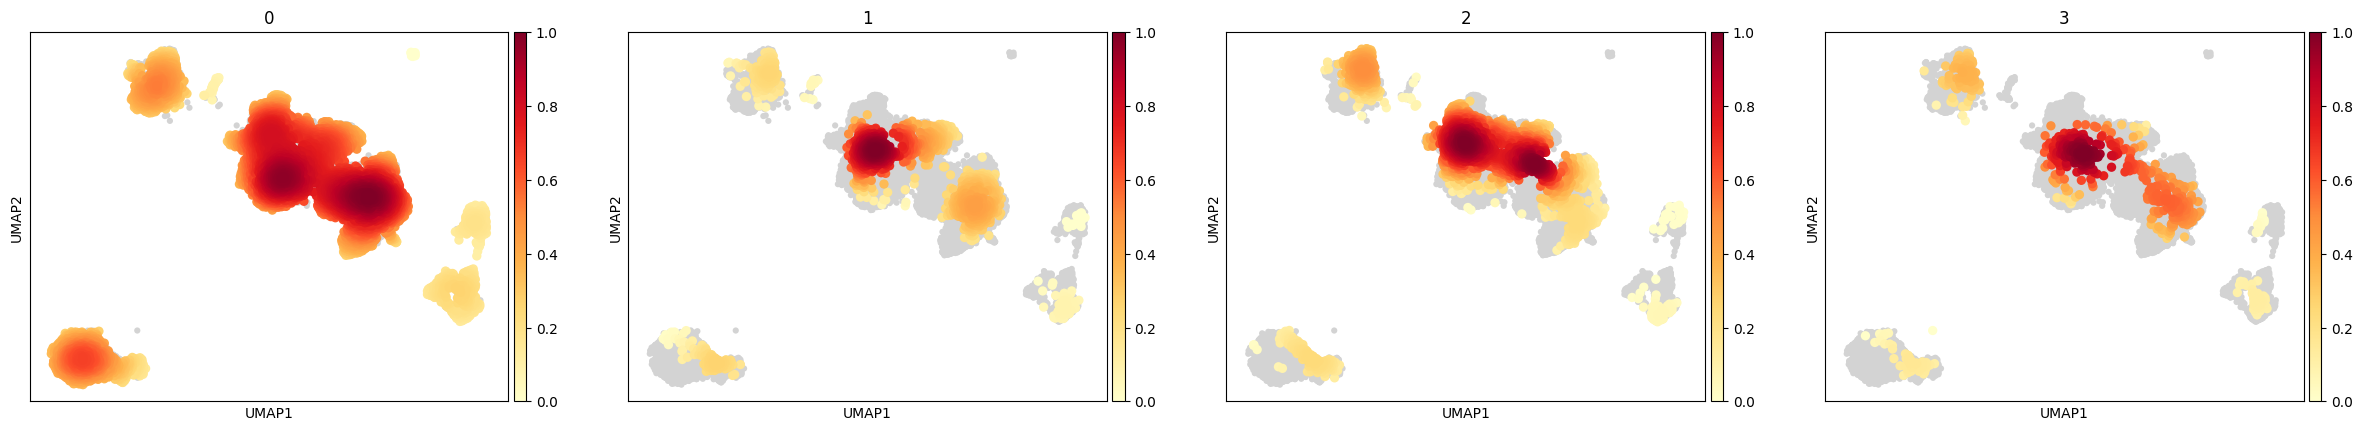

In [31]:
sc.pl.embedding_density(adata_concat, groupby="batch")

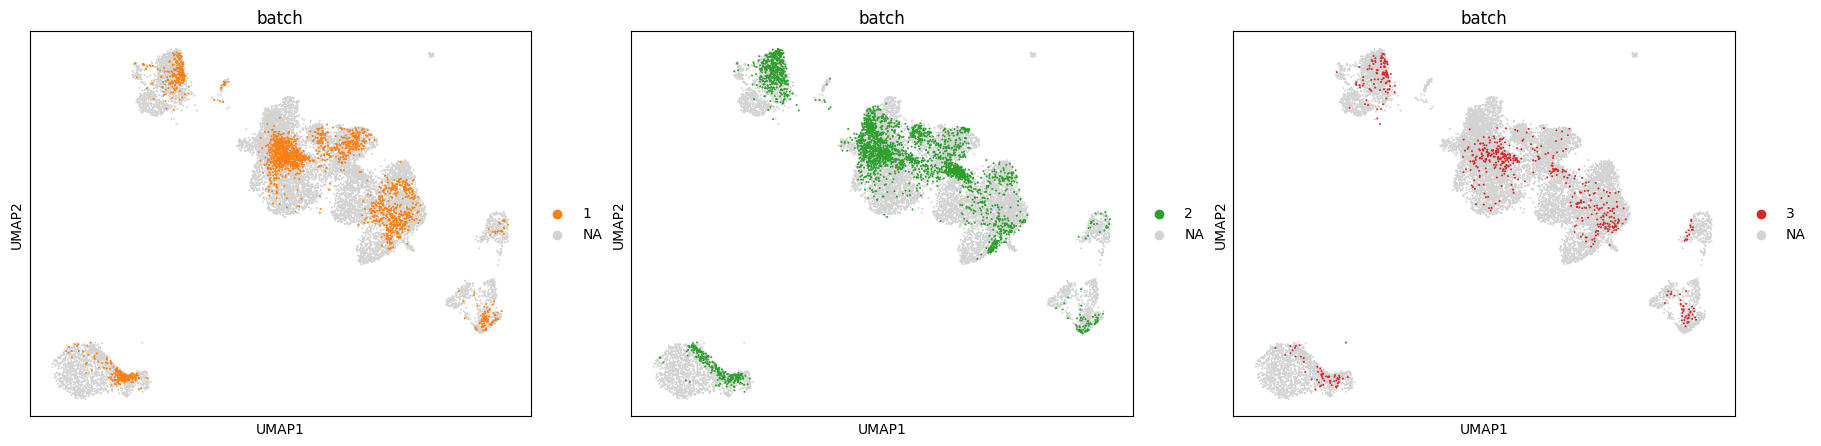

In [35]:
# partial visualizaton of a subset of groups in embedding
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for batch, ax in zip(["1", "2", "3"], axes, strict=True):
    sc.pl.umap(adata_concat, color="batch", groups=[batch], ax=ax, show=False)